In [41]:
print("welcome to my Sales Analysis Project using Python🔥")

welcome to my Sales Analysis Project using Python🔥


In [42]:
import pandas as pd

df = pd.read_csv("sales_data.csv")
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   str    
 2   Sales_Rep             1000 non-null   str    
 3   Region                1000 non-null   str    
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   str    
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   str    
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   str    
 12  Sales_Channel         1000 non-null   str    
 13  Region_and_Sales_Rep  1000 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 109.5 KB


In [44]:
df = df.drop_duplicates()
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

In [45]:
df['Revenue'] = df['Unit_Price'] * df['Quantity_Sold']
df['Cost'] = df['Unit_Cost'] * df['Quantity_Sold']
df['Profit'] = df['Revenue'] - df['Cost']

df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Revenue,Cost,Profit
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,4809.96,2749.50,2060.46
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,71560.48,64878.63,6681.85
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,11142.00,7846.80,3295.20
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,174242.25,168871.17,5371.08
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,9005.23,8285.81,719.42


In [46]:
df.groupby('Sales_Rep')['Revenue'].sum().sort_values(ascending=False)

Sales_Rep
David      16395583.95
Eve        15271749.44
Bob        13712628.18
Alice      13397730.09
Charlie    11552249.05
Name: Revenue, dtype: float64

In [47]:
df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

Region
North    18208403.85
East     18077401.05
West     17761568.65
South    16282567.16
Name: Revenue, dtype: float64

In [48]:
df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)

Product_Category
Clothing       19286733.93
Furniture      18330280.56
Electronics    17571040.57
Food           15141885.65
Name: Revenue, dtype: float64

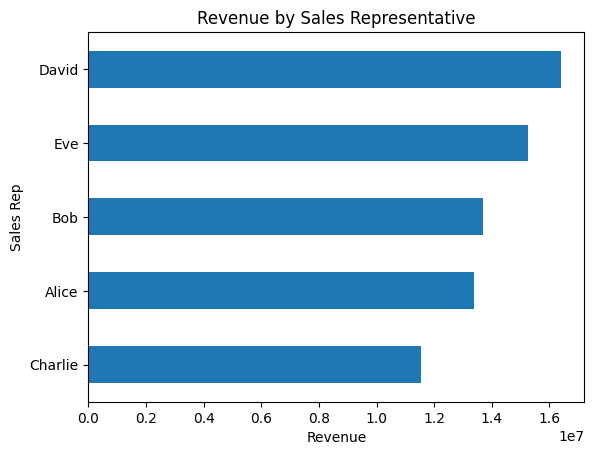

In [49]:
df.groupby('Sales_Rep')['Revenue'].sum().sort_values().plot(kind='barh')

plt.title("Revenue by Sales Representative")
plt.xlabel("Revenue")
plt.ylabel("Sales Rep")

plt.show()

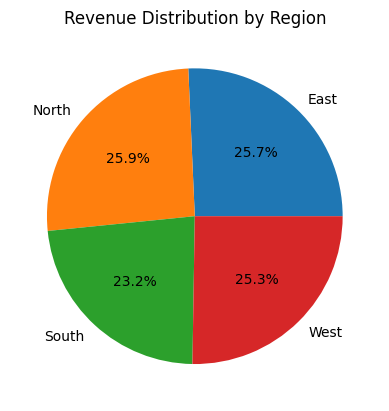

In [50]:
df.groupby('Region')['Revenue'].sum().plot(kind='pie', autopct='%1.1f%%')

plt.title("Revenue Distribution by Region")
plt.ylabel("")

plt.show()

In [51]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

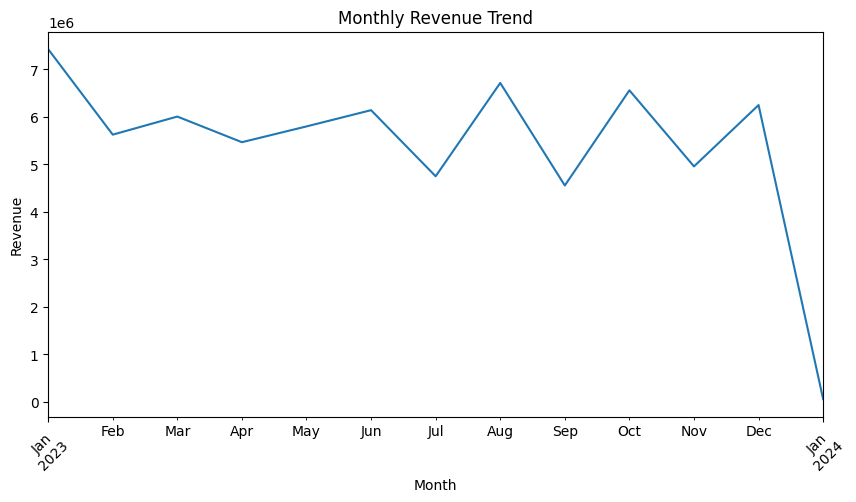

In [52]:
# Convert to datetime
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])


# Create Month column
df['Month'] = df['Sale_Date'].dt.to_period('M')

# Group by month
monthly_revenue = df.groupby('Month')['Revenue'].sum()


plt.figure(figsize=(10,5))
# Plot
import matplotlib.pyplot as plt

monthly_revenue.plot(kind='line')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")



plt.xticks(rotation=45)
plt.show()

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Clothing'),
  Text(1, 0, 'Electronics'),
  Text(2, 0, 'Food'),
  Text(3, 0, 'Furniture')])

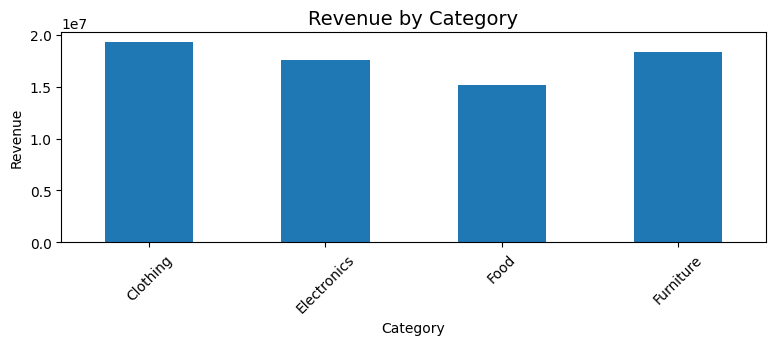

In [54]:
plt.subplot(2, 2, 1)

df.groupby('Product_Category')['Revenue'].sum().plot(
    kind='bar',
    figsize=(20, 6)   # bar chart size
)

plt.title("Revenue by Category", fontsize=14)

plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)


